During DESeq2, I noticed there are some multiplexing capture genes. These genes include TSB0251, TSB0252, TSB0253, and correspondingly (?) HTO-1, HTO-2, HTO-3. We want to remove these genes from further downstream analysis. 

In [1]:
# Import packages
import os
import pandas as pd
import re
import numpy as np
import glob
from pathlib import Path
from scipy import sparse
from copy import deepcopy
import csv
import itertools
import warnings
import scanpy as sc
from cellbender.remove_background.downstream import anndata_from_h5
from sklearn.utils import shuffle
from anndata import AnnData
import anndata
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns

In the post-processed, highly variable genes file, these genes need to be filtered out, and post-processing needs to be redone. 

In [6]:
# Read the concatenah5ad file
adata_concat = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_concat/adata.combined.h5ad')

In [7]:
# Genes to be filtered out
genes_to_exclude = ['TSB0251', 'TSB0252', 'TSB0253', 'HTO-1', 'HTO-2', 'HTO-3']

# Filter out specified genes
filtered_adata = adata_concat[:, ~adata_concat.var_names.isin(genes_to_exclude)]

# Print or use the filtered AnnData object
print(filtered_adata)

View of AnnData object with n_obs × n_vars = 61925 × 32485
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Sample'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells'
    obsm: 'gene_expression_encoding'


In [8]:
filtered_adata

View of AnnData object with n_obs × n_vars = 61925 × 32485
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Sample'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells'
    obsm: 'gene_expression_encoding'

In [10]:
# Check that the filtered adata does not have the multiplex captured genes
print(filtered_adata.var_names[filtered_adata.var_names.str.startswith('TSB0')])
print(filtered_adata.var_names[filtered_adata.var_names.str.startswith('HTO')])

Index([], dtype='object', name='gene_name')
Index([], dtype='object', name='gene_name')


In [ ]:
# Save the filtered adata 
out_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_concat/'
os.makedirs(out_dir,exist_ok=True)

filtered_adata.write_h5ad(out_dir + 'filtered.adata.combined.h5ad')
filtered_adata.obs.to_csv(out_dir + 'filtered.obs.combined.csv', sep ='\t')

In [3]:
# Start post-processing on the filtered adata
# Read in the filtered, combined adata
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_concat/filtered.adata.combined.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 61925 × 32485
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Sample'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells'
    obsm: 'gene_expression_encoding'

In [3]:
# Read in files
ref_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/scripts/organoid_analysis_pipeline_scripts/'
sample_df = pd.read_csv(ref_dir + 'Organoid_Sample_Description.txt', sep='\t',index_col=0)

import re

mtx_fn = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_scran/' +  'scran_output_matrix.mtx'
g_fn = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_scran/' + 'scran_genes.csv'
bc_fn = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_scran/' + 'scran_barcodes.csv'

fn = g_fn
with open(fn, 'r') as f:
    g = [i.strip() for i in f.readlines()]

fn = bc_fn
with open(fn, 'r') as f:
    bc = [i.strip() for i in f.readlines()]

from scipy.io import mmread
norm_df = mmread(mtx_fn)
norm_df = norm_df.tocsr().toarray()
norm_df = pd.DataFrame(norm_df, index=bc, columns=g)

samples = [re.sub('_[ACGT]+-1$','',i) for i in bc]
samples = pd.Series(samples, index = bc)

bc_intersect = adata.obs.index.intersection(norm_df.index)
g_intersect = adata.var_names.intersection(norm_df.columns)
adata = adata[bc_intersect, g_intersect]
adata.layers["counts"] = adata.X.copy()
norm_df = norm_df.loc[adata.obs.index, adata.var_names]

adata.X = norm_df.values
adata.layers['without_log'] = adata.X

adata.raw = adata  # Save the raw data before log transformation
sc.pp.log1p(adata, base=2)

sample_df2 = sample_df.loc[samples,:]
sample_df2.index = adata.obs.index

adata.obs = pd.concat([adata.obs.drop('Sample', axis=1), sample_df2], axis=1)

adata.obs['Sample'] = adata.obs['Sample'].astype('category')

/scratch/lsftmp/2417793.tmpdir/ipykernel_72700/1338659736.py:30: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


In [4]:
# Find highly variable genes
adata.obs['Batch'] = adata.obs.Batch.astype(str).astype('category')

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=5000,
    layer="counts",
    flavor="seurat_v3",  # Change to "seurat"
    batch_key="Batch"
)

norm_df = pd.DataFrame(adata.X, index=adata.obs_names, columns = adata.var_names)
norm_df = norm_df.loc[:,adata.var.highly_variable]

bad_genes = norm_df.columns.str.contains(
    "^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT")
norm_df = norm_df.loc[:,~bad_genes]

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
import numpy.matlib
def kneepoint(vec):
    curve =  [1-x for x in vec]
    nPoints = len(curve)
    allCoord = np.vstack((range(nPoints), curve)).T
    np.array([range(nPoints), curve])
    firstPoint = allCoord[0]
    lineVec = allCoord[-1] - allCoord[0]
    lineVecNorm = lineVec / np.sqrt(np.sum(lineVec**2))
    vecFromFirst = allCoord - firstPoint
    scalarProduct = np.sum(vecFromFirst * numpy.matlib.repmat(lineVecNorm, nPoints, 1), axis=1)
    vecFromFirstParallel = np.outer(scalarProduct, lineVecNorm)
    vecToLine = vecFromFirst - vecFromFirstParallel
    distToLine = np.sqrt(np.sum(vecToLine ** 2, axis=1))
    idxOfBestPoint = np.argmax(distToLine)
    return idxOfBestPoint

def RunPCA(cts, var_threshold, n_components=300):
    pca = PCA(n_components=n_components, svd_solver='randomized')
    pca.fit(cts)
    num_components = 0
    num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
    num_components = max(num_components,np.where(np.cumsum(pca.explained_variance_ratio_) > var_threshold)[0][0])
    var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
    print('# Components = %d' % (num_components+1))
    print('Variance explained = %f' % var_explained)
    return pca, num_components, var_explained

In [7]:
# Perform further post-processing
'''
PCA
'''
print('Performing PCA')
n_components=500
pca = PCA(n_components=n_components, svd_solver='randomized')
pca.fit(norm_df)

#By Kneepoint
num_components = 0
num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
print('# Components = %d' % (num_components+1))

var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
print('Variance explained = %f' % var_explained)

pca = PCA(n_components=num_components, svd_solver='randomized')
pca_merge = pd.DataFrame(pca.fit_transform(norm_df.values),
                index=norm_df.index)
adata.obsm['X_pca'] = pca_merge.loc[adata.obs_names,:].values
adata.uns['num_components'] = num_components
adata.uns['var_explained'] = var_explained

######################
'''
NEAREST NEIGHBORS
'''
print('Performing nearest neighbors')
n_neighbors=30
min_dist = 0.3
sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=pca_merge.shape[1])

######################
'''
CLUSTERING
'''
print('Phenograph Clustering')
import phenograph
clusters_merge, _, _ = phenograph.cluster(pca_merge, k=30)
clusters_merge = pd.Series(clusters_merge, pca_merge.index)

adata.obs['phenograph'] = clusters_merge.loc[adata.obs_names].astype('str').astype('category')

######################
'''
UMAP
'''
print('Performing UMAP')
sc.tl.paga(adata, groups = 'phenograph')
sc.pl.paga(adata, plot=False)
sc.tl.umap(adata, init_pos='paga', min_dist=min_dist)

Performing PCA
# Components = 50
Variance explained = 0.346024
Performing nearest neighbors
Phenograph Clustering
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 6.473904848098755 seconds
Jaccard graph constructed in 9.977132558822632 seconds
Wrote graph to binary file in 1.0311179161071777 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.926662
After 9 runs, maximum modularity is Q = 0.928092
Louvain completed 29 runs in 52.00501251220703 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 73.17100477218628 seconds
Performing UMAP


In [8]:
# Save the post-processed adata without multiplexing capture genes
out_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/'
os.makedirs(out_dir,exist_ok=True)

adata.write_h5ad(out_dir + 'adata.filteredmultiplex.combined.hvg_5000.h5ad')
adata.obs.to_csv(out_dir + 'obs.filteredmultiplex.combined.hvg_5000.csv', sep ='\t')

In [2]:
# Read in the filtered, combined adata
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/adata.filteredmultiplex.combined.hvg_5000.h5ad')

In [11]:
adata

AnnData object with n_obs × n_vars = 59140 × 32485
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'umap', 'var_explained'
    obsm: 'X_pca', 'X_umap', 'gene_expression_encoding'
    layers: 'counts', 'without_log'
 

In [12]:
# Check that the filtered adata does not have the multiplex captured genes
print(adata.var_names[adata.var_names.str.startswith('TSB0')])
print(adata.var_names[adata.var_names.str.startswith('HTO')])

Index([], dtype='object', name='gene_name')
Index([], dtype='object', name='gene_name')


In [ ]:
# Plot the filtered, combined adata
color_labels = {}
for col, i in zip(['blue','red'],['BASE','HISC']):
    for shade,j in zip(['light',''],['CTRL','ZFPKD']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'
color_labels
            
fig, ax=plt.subplots(1,1, figsize=(3.8,3.8))

# Add missing keys
# color_labels['ZFPKD-HISC'] = 'red'  
# color_labels['ZFPKD-BASE'] = 'blue'  
# color_labels['CTRL-BASE'] = 'lightblue'  
# color_labels['CTRL-HISC'] = 'pink'  

ind1 = adata.obs.Tumor_Site=='Primary'
ind2 = adata.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values & ind2.values

adata1 = adata[ind,:]

umap = adata1.obsm['X_umap']
plot_df = adata1.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

g = sns.scatterplot(data=plot_df, x='x',y='y', style='Patient', hue='Condition',
                    markers = {'125': 'o', '146': 'X'}, 
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary',fontsize=20)

In [53]:
import sklearn
sklearn.__version__

'1.3.2'

In [3]:
#################

from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

import numpy.matlib
def kneepoint(vec):
    curve =  [1-x for x in vec]
    nPoints = len(curve)
    allCoord = np.vstack((range(nPoints), curve)).T
    np.array([range(nPoints), curve])
    firstPoint = allCoord[0]
    lineVec = allCoord[-1] - allCoord[0]
    lineVecNorm = lineVec / np.sqrt(np.sum(lineVec**2))
    vecFromFirst = allCoord - firstPoint
    scalarProduct = np.sum(vecFromFirst * numpy.matlib.repmat(lineVecNorm, nPoints, 1), axis=1)
    vecFromFirstParallel = np.outer(scalarProduct, lineVecNorm)
    vecToLine = vecFromFirst - vecFromFirstParallel
    distToLine = np.sqrt(np.sum(vecToLine ** 2, axis=1))
    idxOfBestPoint = np.argmax(distToLine)
    return idxOfBestPoint

def RunPCA(cts, var_threshold, n_components=300):
    pca = PCA(n_components=n_components, svd_solver='randomized')
    pca.fit(cts)

    num_components = 0
    num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
    num_components = max(num_components,np.where(np.cumsum(pca.explained_variance_ratio_) > var_threshold)[0][0])
    var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
    print('# Components = %d' % (num_components+1))
    print('Variance explained = %f' % var_explained)
    return pca, num_components, var_explained

In [19]:
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_concat/adata.combined.h5ad')

In [20]:
bad_genes = adata.var_names[adata.var_names.str.contains('^(HTO|TSB0)', regex=True)]

/scratch/lsftmp/2480267.tmpdir/ipykernel_173587/2254884118.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  bad_genes = adata.var_names[adata.var_names.str.contains('^(HTO|TSB0)', regex=True)]


In [21]:
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_concat/adata.combined.h5ad')

adata = adata[:,~adata.var_names.isin(bad_genes)]

ref_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/scripts/organoid_analysis_pipeline_scripts/'
sample_df = pd.read_csv(ref_dir + 'Organoid_Sample_Description.txt', sep='\t',index_col=0)

import re

mtx_fn = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_scran/' +  'scran_output_matrix.mtx'
g_fn = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_scran/' + 'scran_genes.csv'
bc_fn = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_scran/' + 'scran_barcodes.csv'

In [22]:
fn = g_fn
with open(fn, 'r') as f:
    g = [i.strip() for i in f.readlines()]

fn = bc_fn
with open(fn, 'r') as f:
    bc = [i.strip() for i in f.readlines()]

from scipy.io import mmread
norm_df = mmread(mtx_fn)
norm_df = norm_df.tocsr().toarray()
norm_df = pd.DataFrame(norm_df, index=bc, columns=g)

norm_df = norm_df.loc[:, ~norm_df.columns.isin(bad_genes)]

In [23]:
norm_df

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A3GALT2,A4GALT,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
146P_BASE_shZFP36L2_3_TTAGGGTCAGTAACGG-1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,3.975665,0.0,0.000000,0.000000,0.0,1.325222,0.000000,0.000000
KG146Li_BASE_shZFP36L2_4_CGTTAGACACGTAACT-1,0.0,0.0,6.907233,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
146P_BASE_shCTRL_AGGTGTTCATACAGGG-1,0.0,0.0,2.517393,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,2.517393,0.000000,0.000000
146P_BASE_shZFP36L2_4_CCTCTAGGTCGCATTA-1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,1.851236,0.000000,0.0,0.925618,0.000000,0.0,0.925618,0.925618,0.000000
125P_HISC_shZFP36L2_3_GTTGTCCTCCACTGGG-1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125P_HISC_shZFP36L2_4_TTCGGTCTCCGTTGGG-1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,1.196693,0.0,1.196693,0.000000,0.000000
146P_HISC_shZFP36L2_4_ACAAAGATCATCACTT-1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.855341,0.000000,0.855341,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.855341
146P_BASE_shZFP36L2_3_TCAGGTAAGTTTAGGA-1,0.0,0.0,1.439818,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,1.439818,0.000000,0.0,0.000000,0.000000,0.0,2.879636,0.000000,1.439818
146P_HISC_shZFP36L2_3_TCATCATAGATCGGTG-1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000


In [26]:
norm_df.columns.str.contains(
    "^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT").sum()

214

In [34]:
norm_df.sum().sum()

663408189.8885398

In [35]:
samples = [re.sub('_[ACGT]+-1$','',i) for i in bc]
samples = pd.Series(samples, index = bc)

bc_intersect = adata.obs.index.intersection(norm_df.index)
g_intersect = adata.var_names.intersection(norm_df.columns)
adata = adata[bc_intersect, g_intersect]
adata.layers["counts"] = adata.X.copy()
norm_df = norm_df.loc[adata.obs.index, adata.var_names]

adata.X = norm_df.values
adata.layers['without_log'] = adata.X

adata.raw = adata  # Save the raw data before log transformation
sc.pp.log1p(adata, base=2)

sample_df2 = sample_df.loc[samples,:]
sample_df2.index = adata.obs.index

adata.obs = pd.concat([adata.obs.drop('Sample', axis=1), sample_df2], axis=1)

adata.obs['Sample'] = adata.obs['Sample'].astype('category')

/scratch/lsftmp/2480267.tmpdir/ipykernel_173587/2095489229.py:7: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


In [36]:
#####

adata.obs['Batch'] = adata.obs.Batch.astype(str).astype('category')

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=5000,
    layer="counts",
    flavor="seurat_v3",  # Change to "seurat"
    batch_key="Batch"
)


In [45]:
adata.var.index[adata.var['highly_variable']]

Index(['A2ML1', 'AADACL2', 'AADACL2-AS1', 'AADAT', 'AARD', 'ABAT', 'ABCA1',
       'ABCA13', 'ABCA4', 'ABCA9-AS1',
       ...
       'ZNF99', 'ZNRF2', 'ZNRF3', 'ZPLD1', 'ZPR1', 'ZRANB2-AS2', 'ZSCAN12',
       'ZSCAN23', 'ZSCAN32', 'ZWINT'],
      dtype='object', name='gene_name', length=5000)

In [46]:
norm_df = pd.DataFrame(adata.X, index=adata.obs_names, columns = adata.var_names)
norm_df = norm_df.loc[:,adata.var.highly_variable]

bad_genes = norm_df.columns.str.contains(
    "^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT")
norm_df = norm_df.loc[:,~bad_genes]

In [50]:
norm_df.max().max()

12.352435787333997

In [55]:
'''
PCA
'''
print('Performing PCA')
n_components=500
pca = PCA(n_components=n_components, svd_solver='randomized')
pca.fit(norm_df)

#By Kneepoint
num_components = 0
num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
print('# Components = %d' % (num_components+1))


Performing PCA
# Components = 50


In [57]:
kneepoint(np.cumsum(pca.explained_variance_ratio_))

49

In [51]:


var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
print('Variance explained = %f' % var_explained)

pca = PCA(n_components=num_components, svd_solver='randomized')
pca_merge = pd.DataFrame(pca.fit_transform(norm_df.values),
                index=norm_df.index)
adata.obsm['X_pca'] = pca_merge.loc[adata.obs_names,:].values
adata.uns['num_components'] = num_components
adata.uns['var_explained'] = var_explained

Performing PCA
# Components = 50
Variance explained = 0.345686


In [54]:
kneepoint(np.cumsum(pca.explained_variance_ratio_))

10

{'BASE-CTRL': 'lightblue', 'BASE-ZFP_KD': 'blue', 'HISC-CTRL': 'pink', 'HISC-ZFP_KD': 'red'}


/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Primary')

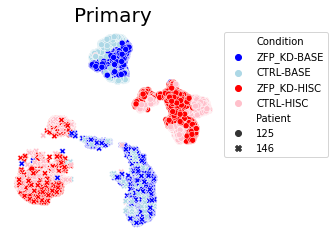

In [61]:
color_labels = {}
for col, i in zip(['blue','red'],['BASE','HISC']):
    for shade,j in zip(['light',''],['CTRL','ZFP_KD']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'
print(color_labels)
            
fig, ax=plt.subplots(1,1, figsize=(3.8,3.8))

# Add missing keys
color_labels['CTRL-BASE'] = 'lightblue'  
color_labels['ZFP_KD-BASE'] = 'blue'  
color_labels['CTRL-HISC'] = 'pink'  
color_labels['ZFP_KD-HISC'] = 'red'  

ind1 = adata.obs.Tumor_Site=='Primary'
ind2 = adata.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values & ind2.values

adata1 = adata[ind,:]

umap = adata1.obsm['X_umap']
plot_df = adata1.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

g = sns.scatterplot(data=plot_df, x='x',y='y', style='Patient', hue='Condition',
                    markers = {125: 'o', 146: 'X'}, 
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary',fontsize=20)

In [18]:
bad_genes.sum()

20

In [15]:
norm_df.columns.isin(bad_genes).any()

False

In [60]:


######################
'''
NEAREST NEIGHBORS
'''
print('Performing nearest neighbors')
n_neighbors=30
min_dist = 0.3
sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=pca_merge.shape[1])

######################
'''
CLUSTERING
'''
print('Phenograph Clustering')
import phenograph
clusters_merge, _, _ = phenograph.cluster(pca_merge, k=30)
clusters_merge = pd.Series(clusters_merge, pca_merge.index)

adata.obs['phenograph'] = clusters_merge.loc[adata.obs_names].astype('str').astype('category')

######################
'''
UMAP
'''
print('Performing UMAP')
sc.tl.paga(adata, groups = 'phenograph')
sc.pl.paga(adata, plot=False)
sc.tl.umap(adata, init_pos='paga', min_dist=min_dist)

Performing nearest neighbors
Phenograph Clustering
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 2.7322237491607666 seconds
Jaccard graph constructed in 14.213137865066528 seconds
Wrote graph to binary file in 0.82602858543396 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.926766
Louvain completed 21 runs in 32.081207513809204 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 55.37908697128296 seconds
Performing UMAP


/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Primary')

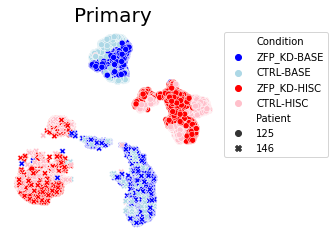

In [62]:
color_labels = {}
for col, j in zip(['blue','red','orange'],['BASE','HISC','Dedifferentiated']):
    for shade,i in zip(['light',''],['CTRL','ZFP_KD']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'
        if color_labels[i + '-' + j] =='darkred':
            color_labels[i + '-' + j] = 'orange'
        if color_labels[i + '-' + j] =='lightorange':
            color_labels[i + '-' + j] = 'moccasin'

fig, ax=plt.subplots(1,1, figsize=(3.8,3.8))

ind1 = adata.obs.Tumor_Site=='Primary'
ind2 = adata.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values & ind2.values

adata_tmp = adata[ind,:]

umap = adata_tmp.obsm['X_umap']
plot_df = adata_tmp.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

g = sns.scatterplot(data=plot_df, x='x',y='y', style='Patient', hue='Condition',
                    markers = {125: 'o', 146: 'X'},
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary',fontsize=20)
